# Detection Theory - Homework 

By Octave Jeanne

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# 1.  Gestalt Essay

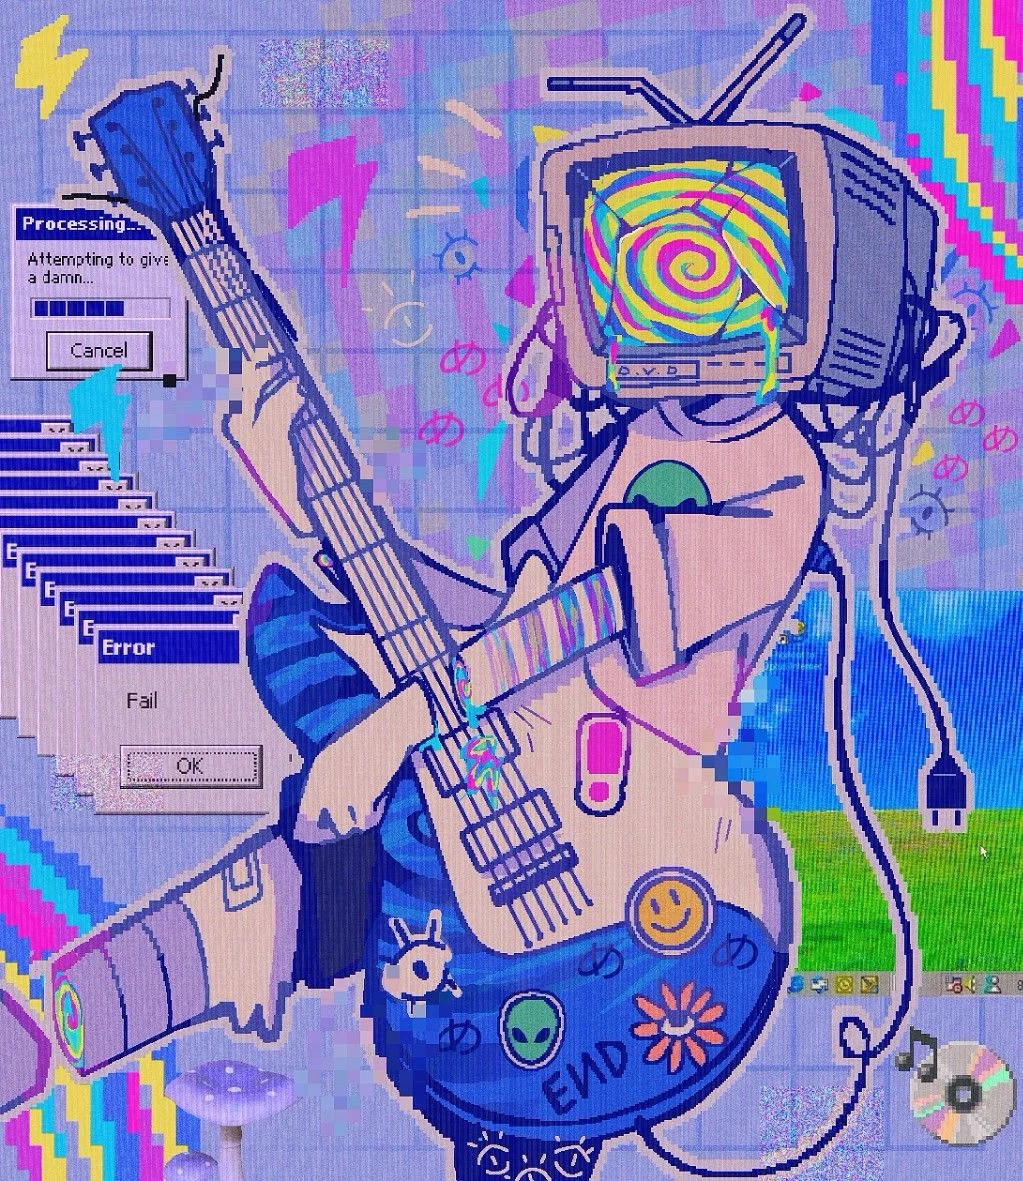

Most drawing and artistic pieces in general are progressively built by combining simple curves into simple shapes and assembling them to form complex structures that can then be interpreted by the viewer. This makes drawings good example of how Gestalt theory can be applied. This small essay highlight this statement in a non-exhaustive way.

The upper drawing starts from simple elements. Curves and straight lines are used to define boundaries (body, guitar, computer tabs, ...) and elementary details (guitar cords, cables, TV's ventillation). Imbricated discs are used for the raindows. Color puddles are used for the blood-like fluid. Elementary graffities (alien head, bretzel, eye) are spread around the character. Grouping these elementary entities yields simple shapes. Boundaries indentify volumes and surfaces such as the two cubes that make up for the TV head or pear-like shape that make up for the guitar. The main distinction between surfaces and volumes is the presence of a vanishing point, for example the head is a volume whereas the computer tabs are surfaces. Once the shapes are defined, T-junctions are used to add depth, by emulating overlap. This is seen through the T-junction that indicate that the guitar covers the body and that the left arm covers the guitar. Similarly, the error tabs are covering one another.  

However, Gestalt goes beyond defining shapes and volumes. It can be used to infer what is "hidden" by similarity (alien head on the t-shirt through its counterpart on the guitar), proximity (error tabs), continuity of direction (a closer look shows that the arm and legs are actually cut), closure (blurry guitar left boundary). Our past experiences also help with the task of giving meaning to the image, as we are likely to recognize a human body or computer tabs. More global of Gestalt theory can also be viewed. The horizontal guitar cords inherit a sense of verticality through their association with the overall guitar or their grouping. Structural coherence also plays since the fact that most of the lower body of the character is missing doesn't pose a problem to identify its parts.

Color is also a key point of this image. X-junctions with the barground's grid and lower pixel intensity make the "rainbow radiation" around the character's head seem transparent. Additionnally, in the right computer tab, the land can be distinguished from the sky because one is green and the other is blue.



# 2. Birthdays in a Class

Consider a class of $30$ students and assume that their birthdays are independent and uniformly distributed variables over the $365$ days of the year. We call, for
$1 \leq n \leq 30$, $C_n$ the number of n-tuples of students of the class having the same birthday. (This number is computed exhaustively by considering all possible ntuples. If (for example) students 1, 2, and 3 have the same birthday, then we count three pairs, $(1, 2), (2, 3), (3, 1)$.) We also consider $\mathbb{P}_n = \mathbb{P}(C_n \geq 1)$, the probability that there is at least one n-tuple with the same birthday and $p_n$, the probability that there is at least one n-tuple and no (n + 1)-tuple.

### 2.0. Utils

In [2]:
def binom(k,n):

    return math.comb(n, k)

def factorial(n):

    return math.factorial(n)

### 2.1. Prove that $\mathbb{P}_n =  1-\sum_{i=1}^{n-1}p_i$ and $\mathbb{P}_n=\mathbb{P}_{n-1}-p_{n-1}$
---

First we prove that $\mathbb{P}(C_n=0) = \sum_{i=1}^{n-1}p_i$ by induction.

$\textbf{Initialization :}$

Let $n=2$
$$
\begin{align*}
\;\mathbb{P}(C_2=0) &=\mathbb{P}\left[(C_2 = 0,C_1\geq 1)\bigcup (C_2 = 0,C_1= 0)\right]\\
&=\mathbb{P}\left[(C_2 = 0,C_1\geq 1)\right]+\mathbb{P}\left[ (C_2 = 0,C_1= 0)\right]&&\text{By incompatibility}\\
&=\mathbb{P}\left[(C_2 = 0,C_1\geq 1)\right]&&\text{Because $C_1=0$ is impossible}\\
&=p_1&&\text{By definition of $p_1$}

\end{align*}
$$

$\textbf{Induction :}$

Assume that there exist a $n\leq 2$ such that $\mathbb{P}(C_n=0) = \sum_{i=1}^{n-1}p_i$

$$
\begin{align*}
\;\mathbb{P}(C_{n+1}=0) &=\mathbb{P}\left[(C_{n+1} = 0,C_n\geq 1)\bigcup (C_{n+1} = 0,C_n= 0)\right]\\
&=\mathbb{P}\left[(C_{n+1} = 0,C_n\geq 1)\right]+\mathbb{P}\left[ (C_{n+1} = 0,C_n= 0)\right]&&\text{By incompatibility}\\
&=\mathbb{P}\left[(C_{n+1} = 0,C_n\geq 1)\right]+\mathbb{P}(C_{n+1}=0|C_n=0)\mathbb{P}(C_n=0)\\
&=\mathbb{P}\left[(C_{n+1} = 0,C_n\geq 1)\right]+\left(1-\mathbb{P}(C_{n+1}\geq 1|C_n=0)\right)\mathbb{P}(C_n=0)\\
&=\mathbb{P}\left[(C_{n+1} = 0,C_n\geq 1)\right]+\mathbb{P}(C_n=0)&&\text{Because $C_{n+1}\geq 1|C_n=0$ is impossible}\\
&=p_n+\sum_{i=1}^{n-1} p_i&&\text{By induction hypothesis and definition of $p_n$}\\
&=\sum_{i=1}^n p_i
\end{align*}
$$

Therefore, by induction $\forall n\geq 2\quad\mathbb{P}(C_n=0) = \sum_{i=1}^{n-1}p_i$. Since, $C_n=0$ is the complementary of $C_n\geq 1$, this yields
$$
\mathbb{P}_n =  1-\sum_{i=1}^{n-1}p_i
$$

Finally, 
$$
\begin{align*}
\;\mathbb{P}_n &=  1-\sum_{i=1}^{n-1}p_i\\
&=\left[1-\sum_{i=1}^{n-2}p_i\right] - p_{n-1}\\
&=\mathbb{P}_{n-1}-p_{n-1}
\end{align*}
$$

### 2.2. Prove that $\mathbb{E}C_n = \frac{1}{365^{n-1}}\left(\begin{array}{c}30\\n\end{array}\right)$. Check that $\mathbb{E}C_2\approx 1.192$, $\mathbb{E}C_3\approx 0.03047$, $\mathbb{E}C_4\approx 5.6\times 10^{-4}$.
---

$C_n$ counts the number of different n-tuples that can be made from student of the class and where all sampled student share their birthday. If we see the event "the sampled n-tuple satisfies that all its individual share their birthday" as a sucess, then $C_n$ follows a binomial distribution where :
- The numbder of trial is the number of different n-tuples among 30 student, i.e $N = \left(\begin{array}{c}30\\ n\end{array}\right)$
- The probability of success is the probability that n student taken at random share their birthday (under the simplifying assumption that 29/02 does not exist), i.e $p = \frac{1}{365^{n-1}}$ by independance.

Hence 
$$
\begin{align*}
\mathbb{E}[C_n] &= Np&&\text{Because $C_n\sim\mathcal{B}(N,p)$}\\
&=\left(\begin{array}{c}30\\ n\end{array}\right)\frac{1}{365^{n-1}}
\end{align*}
$$

$\textbf{Sanity check :}$

In [3]:
def EC_n(n, D = 30):
    return math.comb(D, n)/(365**(n-1))

for n in range(2,5):
    print(f'EC_{n} = {EC_n(n)}\n')

EC_2 = 1.1917808219178083

EC_3 = 0.030474760743103773

EC_4 = 0.0005635743425094533



### 2.3. Prove that $\mathbb{P}(C_2 = 0)=\frac{365\times ...\times 336}{365^{30}}\approx 0.294$. Deduce that $\mathbb{P}_2 \approx 0.706$.
---

Having $C_2 = 0$ means everybody in the class have a different birthday. 
- The number of ways to get a set of 30 different birthday configuration is $\left(\begin{array}{c}365\\30\end{array}\right)$. 
- The number of ways to assign each birthday to each student is $30!$
- Therefore, the number of configurations where everybody has a different birthday is $30!\times \left(\begin{array}{c}365\\30\end{array}\right)$
- By independence, we know that the probability of having a specific 30-tuple is $\frac{1}{365^{30}}$. 

This yields

$$
\begin{align*}
\;\mathbb{P}(C_2=0)&=30!\left(\begin{array}{c}365\\30\end{array}\right)\frac{1}{365^{30}}\\
&=\frac{365\times...\times 336}{365^{30}}
\end{align*}
$$

$\textbf{Numerical application :}$

In [4]:
fact_30 = 1
for i in range(1,31):
    fact_30 *= i

fact_30*math.comb(365, 30)/(365**30)

0.2936837572807313

$$
\begin{align*}
\mathbb{P}_2&=\mathbb{P}(C_2\geq 1)\\
&=1-\mathbb{P}(C_2=0)&&\text{By complementarity}\\
&\approx 0.706&&\text{Because $\mathbb{P}(C_2=0)\approx 0.294$}
\end{align*}
$$

### 2.4. Prove that
---

$$
p_2 = \frac{1}{365^{30}}\sum_{i=1}^{15}\frac{\prod_{j=1}^i \left(\begin{array}{c}32-2j\\2\end{array}\right)}{i!}\prod_{k=0}^{29-i}(365-k)
$$

$p_2$ 

- 30 days sequence : $\frac{1}{365^{30}}$

- Number of pairs $\sum_{i=1}^{15} (...)$

- Pair assignment : $\prod_{j=1}^i \left(\begin{array}{c}32 - 2j\\2\end{array}\right)$

- No pair assignment : $(30-2i)!$

- Pair assignment : $i!$

- Days selection $\left(\begin{array}{c}365\\29-i\end{array}\right)$

$$
\begin{align*}
\; &p_2&&=\mathbb{P}(C_3 = 0, C_2\leq 1)\\
&&&=\sum_{i=1}^{15} \mathbb{P}(C_3 = 0,C_2 = i),\quad \text{Because the maximal amount of pair that can be formed within $30$ is $15$}
\end{align*}
$$

Let us consider $\mathbb{P}(C_3 = 0, C_2 = i)$. We adopt the framework
$$
\mathbb{P}(C_3 = 0,C_2 = i) = \frac{\text{favorable cases}}{\text{total cases}}
$$

- Let us count the number of favorable cases :
    - First there is $30 - i$ days to sample to assign the birthdays. This gives $\prod_{k=0}^{29-i}(365 - k)$ possible days arrangement.
    - Then, people need to be assigned to their birthday. That means considering every possible pair-assignment wise configuration. If we cared about the order of assignment that number would be $\prod_{j = 1}^i \left(\begin{array}{c}32-2j\\\\2\end{array}\right)$. In our case, the assignment order is not important, so we add a $i!$ correcton (i.e the number of ways to specify the order of assignment). This gives $\frac{1}{i!}\prod_{j = 1}^i \left(\begin{array}{c}32-2j\\\\2\end{array}\right)$
        
    - In summary 
    $$
    \text{favorable cases} = (30-i)!\prod_{j = 1}^i \left(\begin{array}{c}32-2j\\\\2\end{array}\right)\prod_{k=0}^{29-i}(365 - k)
    $$

- The number of total cases is just taking 30 days in the 365 considered one, with no duplicata constrains. That is $\text{total cases} = 365^{30}$

Hence, 
$$
\begin{align*}
\;&\mathbb{P}(C_3 = 0,C_2 = i) &&= \frac{\text{favorable cases} }{\text{total cases}}\\
&&&=\frac{1}{365^{30}}\cdot \prod_{j = 1}^i \left(\begin{array}{c}32-2j\\\\2\end{array}\right)\prod_{k=0}^{29-i}(365 - k)
\end{align*}
$$

So we can use it to finally have
$$
p_2 = \sum_{i=1}^{15}\frac{1}{365^{30}}\cdot \prod_{j = 1}^i \left(\begin{array}{c}32-2j\\\\2\end{array}\right)\prod_{k=0}^{29-i}(365 - k)
$$

### 2.5. Compute $p_2$
---

In [5]:
p2 = 0
for i in range(1,16):
    n_pair_assignment = 1
    for j in range(1,i+1):
        n_pair_assignment *= binom(k = 2, n = 32-2*j)
    
    other = 1
    for k in range(30-i):
        other *= 365 - k
    
    subtotal = n_pair_assignment*other/factorial(i)
        
    p2 += subtotal

p2 /= 365**30
print(p2)

0.677785738974939


### 2.6. Deduce that $\mathbb{P}_3\approx 0.0285$
---

We use the relation that was proven in the first question : 
$$
\begin{align*}
\;\mathbb{P}_3&=\mathbb{P}_2 - p_2\\
&\approx 0.706 - 0.678\\
&\approx 0.0285
\end{align*}
$$

### 2.7. We denote by $[r]$ the integer part of a real number. Prove that 
$$
p_3 = \frac{1}{365^{30}}\sum_{i=1}^{10}\frac{\prod_{j=1}^i \left(\begin{array}{c}33-3j\\3\end{array}\right)}{i!}\left[\prod_{k=0}^{29 - 2i}(365-k)+\sum_{l=1}^{\left[ \frac{30-3i}{2}\right]}\frac{\prod_{m=1}^l \left(\begin{array}{c}30-3i+2-2m\\2\end{array}\right)}{l!}\prod_{n=0}^{29-2i-l}(365-n)\right]
$$
---

$$
\begin{align*}
\;&p_3 &&=\mathbb{P}(C_4 = 0, C_3\geq 1)&&=\sum_{i=10}\mathbb{P}(C_4 = 0, C_3 = i),\quad\text{Following the same reasonning as question 4 but for the triplet}
\\&&&=\sum_{i=10}\mathbb{P}(C_4 = 0, C_3 = i, C_2 = i) +\mathbb{P}(C_4 = 0, C_3 = i, C_2 \geq i),\quad\text{There can be pairs that are not in triplet}\\
&&&=\sum_{i=10}\mathbb{P}(C_4 = 0, C_3 = i, C_2 = i) +\sum_{l = 1}^{\left[ \frac{30-3i}{2}\right]}\mathbb{P}(C_4 = 0, C_3 = i, C_2 = i+l),\quad \text{With the same reasonning before with an integer constrain}
\end{align*}

$\textbf{Consider } \mathbb{P}(C_4 = 0, C_3 = i, C_2 = i)$ : 

We use a Number of favorable cases / Number of tests reasoning. Note that $C_2 = i$ and $C_3 = i$ means that the pairs are already identified by their triplet, so they should not be accounted for. 

Favorable cases :
- Sampling days : Considering that $i$ days are taken for the triplet, there is $30 -2i$ days to sample. That gives $\prod_{k=0}^{29-2i}(365-k)$ possibilities.
- Assigning triplets : Similarly to question 4, we do the assignment without caring for the order so that gives $\frac{\prod_{j=1}^i \left(\begin{array}{c}33-3j\\3\end{array}\right)}{i!}$ possibilities.

Number of tests : $365^{30}$

To sum up
$$
\mathbb{P}(C_4 = 0, C_3 = i, C_2 = i) = \frac{\prod_{j=1}^i \left(\begin{array}{c}33-3j\\3\end{array}\right)}{i!}\prod_{k=0}^{29-2i}(365-k)
$$

$\textbf{Consider } \mathbb{P}(C_4 = 0, C_3 = i, C_2 = i+l)$ : 

There is $i$ pairs that are identified by the triplet and should not be accounted for. That lives $l$ pairs to consider. Same as before, we use a Number of favorable cases / Number of tests reasoning.

Favorable cases :
- The triplet assignment stays unchanged so we keep the  $\frac{\prod_{j=1}^i \left(\begin{array}{c}33-3j\\3\end{array}\right)}{i!}$ factor. 
- There is now $l$ pairs to assign. Following question 4 and remarking that there is now $30 - 2i$ days left to do the assignment yields a factor of $\frac{\prod_{m=1}^l \left(\begin{array}{c}30-3i+2-2m\\2\end{array}\right)}{l!}$.
- The number of days to sample should account for the number of pairs and number of triplet. Since we have $i$ triplet and $l$ additionnal pairs, the effective number of days to sample is $30-2i-l$. This gives a factor of $\prod_{n=0}^{29-2i-l}(365-n)$.

Number of tests : $365^{30}$. 

To sum up
$$
 \mathbb{P}(C_4 = 0, C_3 = i, C_2 = i+l) = \frac{\prod_{j=1}^i \left(\begin{array}{c}33-3j\\3\end{array}\right)}{i!}\frac{\prod_{m=1}^l \left(\begin{array}{c}30-3i+2-2m\\2\end{array}\right)}{l!}\prod_{n=0}^{29-2i-l}(365-n)
$$


Merging the three equality that we got up to now and factorizing by the $l$-independent part gives the desired result

$$
p_3 = \frac{1}{365^{30}}\sum_{i=1}^{10}\frac{\prod_{j=1}^i \left(\begin{array}{c}33-3j\\3\end{array}\right)}{i!}\left[\prod_{k=0}^{29 - 2i}(365-k)+\sum_{l=1}^{\left[ \frac{30-3i}{2}\right]}\frac{\prod_{m=1}^l \left(\begin{array}{c}30-3i+2-2m\\2\end{array}\right)}{l!}\prod_{n=0}^{29-2i-l}(365-n)\right]
$$


### 2.8. Deduce by a computer program that $p_3\approx 0.027998$ and $\mathbb{P}_4\approx 5.4\times 10^{-4}$.
---

In [6]:
p3 = 0

for i in range(1,11):
    number_of_triplet = 1
    for j in range(1,i+1):
        number_of_triplet *= binom(k = 3, n = 33-3*j)
    
    left_term_bracket = 1
    for k in range(30-2*i):
        left_term_bracket *= 365-k

    right_term_bracket = 0
    for l in range(1, (30-3*i)//2+1):

        prod_frac = 1
        for m in range(1,l+1):
            prod_frac *= binom(k = 2, n = 30-(3*i)+2-(2*m))

        prod_other = 1
        for n in range(29-2*i-l+1):
            prod_other *= 365 - n
        
        right_term_bracket += prod_frac*prod_other/factorial(l)
    
    bracket = left_term_bracket + right_term_bracket

    p3 += number_of_triplet*bracket/factorial(i)

p3 /= 365**30

print(p3)

0.02799822429022041


$$
\begin{align*}
\;\mathbb{P}_4&=\mathbb{P}_3 - p_3\\
&\approx 0.0285- 0.027998\\
&\approx 5.4\times 10^{-4}
\end{align*}
$$

### 2.9. Be courageous and give a general formula for $p_n$
---

### 2.10. Prove that $\mathbb{E}C_{30} = \mathbb{P}_{30} = \frac{1}{365^{29}}$, $\mathbb{E}C_{29}=\frac{30}{365^{28}}$, and $\mathbb{P}_{29}=\frac{30\times 364+1}{365^{29}}$
---

The only achievable value for $C_{30}$ is one so $\mathbb{P}(C_{30} = 1) =  \mathbb{P}(C_{30} \geq 1) = \mathbb{P}_3$. Thus $\mathbb{E}[C_{30}] = 1\cdot \mathbb{P}_{30} = \mathbb{P}_{30}$. 

Additonnally, $C_{30}$ means that everyone share the same brirthday, considering every possible value for this day gives $\mathbb{P}_{30} = \sum_{i = 1}^{365}\frac{1}{365^{30}} = \frac{1}{365^{29}}$

$C_{29}$ is the number of $29$ tuples that can be made from 30 student through 365 days. It can only have values 0 or 1 given that we have 30 student. 
- There is $\left(\begin{array}{c}30\\29\end{array}\right) = 30$ ways to get the tuple. Given a tuple, $29$ people must share a birthdat which has probability $\frac{1}{365^{28}}$ Hence 
$$
\mathbb{E}[C_{29}] = \mathbb{P}(C_{29} = 1) = \sum_{i = 1}^{365}\left(\begin{array}{c}30\\29\end{array}\right)\frac{1}{365^{29}} = \frac{30}{365^{28}}
$$

For $C_{29}$ the same reasonning applies except that now, everyone besides one person share their birthday :
- Person to have a different birthday : $\left(\begin{array}{c}30\\1\end{array}\right)$
- Value of the different birthday : $\left(\begin{array}{c}365\\1\end{array}\right)$
- Value of the others' birthday : $\left(\begin{array}{c}365 - 1\\1\end{array}\right)$
- There is also the case where 30 student share the same birthday so we have to add $\mathbb{P}_3$

To sum up
$$
\begin{align*}
\;&\mathbb{P}_{29} &&= \frac{\left(\begin{array}{c}30\\1\end{array}\right)\left(\begin{array}{c}365 \\1\end{array}\right)\left(\begin{array}{c}365 - 1\\1\end{array}\right)}{365^{30}} +\mathbb{P}_3 \\
&&&=\frac{30\times 365\times 364}{365^{30}}+\frac{1}{365^{29}}\\
&&&= \frac{30\times 364 + 1}{365^{29}}
\end{align*}
$$



### 2.11. Plot for each n
---

### 2.12. Explain why $\mathbb{P}_n$ and $\mathbb{E}C_n$ are so close for $n\geq 3$
---

In this exercise, we implicitly conducted a $\text{Number of tests}\times \text{Probability of event}$ type framework. The probability of event ($\frac{1}{365^{30}}$) was very small whereas the number of test was dependent on $n$. For small $n$, i.e $n\leq 2$, the number of test was extremelly high, making it likely to observe rare events. These rare events caused $\mathbb{P}_n$ to be significantly different for $\mathbb{E}C_n$. However, as $n$ grew, the number of test importantly decreases, making $\mathbb{P}_n$ get closer to $\mathbb{E}C_n$ until reaching it for $n = 30$.

# 3. Hoeffding's Inequality for a Sum of Random Variables

Let $(\Omega,\mathcal{F}, \mathbb{P})$ be a probability space. It is recalled that if $X_1$ and $X_2$ are independent variables, and if $f$ and $g$ are two measurable functions from $\mathbb{R}$ to $\mathbb{R}$, then $f(X_1)$ and $g(X_2)$ are also independent. It is also recalled that if $X_1, ..., X_l$ are independent, then $\mathbb{E}\left[\prod_{i=1}^l\right] = \prod_{i=1}^l \mathbb{E}[X_i]$.

Let $X_1,..., X_l$ be independent random variables satisfying $0<X_i< 1$. Let $S_l = \sum_{i=1}^l X_i$ and $p = \mathbb{E}\left[\frac{S_l}{l}\right]$. We will prove that for $0<t<1-p$, 
$$
\mathbb{P}\left[S_l \geq (p+t)l\right]\leq \left(\frac{p}{p+t}\right)^{l(p+t)}\left(\frac{1-p}{1-p-t}\right)^{l(1-p-t)}\leq e^{-lt^2h(p)}\leq e^{-2lt^2}
$$

Where 
$$
h(p) = \frac{1}{1-2p}\log\frac{1-p}{p},\quad\text{if $0<p<\frac{1}{2}$}
$$
and
$$
h(p) = \frac{1}{2p(1-2p)},\quad\text{if $\frac{1}{2}<p<1$}
$$

This kind of inequality is called a “large deviation inequality”. To understand its meaning in a more particular setting, assume that the $X_i$ are i.i.d.. Then when $l$ is
large, we know by the law of large numbers that $S_l\to p$ almost surely. Thus, the Hoeffding inequality estimates an event that is less and less likely when $l$ tends to infinity, namely the event that the mean $\frac{S_l}{l}$ exceeds $p$ by a positive value $t$.


### 3.1.  To understand the meaning of the inequality, draw the graph of the function $h(p)$
---

In [8]:
def h(p):
    if (0 < p) and (p <1/2):
        return (1/(1-2*p))*np.log((1-p)/p)

    else:
        return 1/(2*p*(1-p))

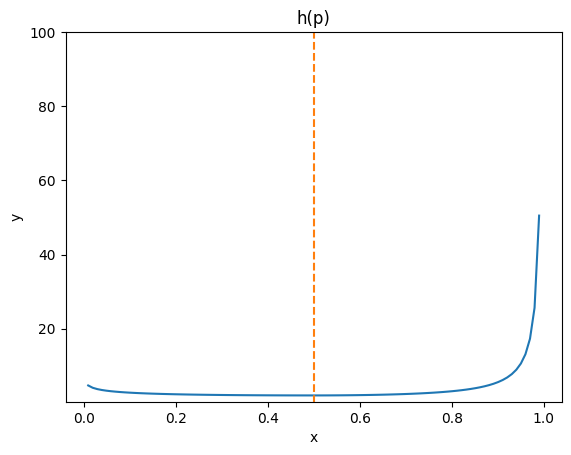

In [9]:
all_p = np.linspace(start = 0.01, stop = 0.99, num = 100)
plt.plot(all_p, [h(p) for p in all_p])
plt.title('h(p)')
plt.xlabel('x')
plt.ylabel('y')
plt.plot([0.5, 0.5], [0.00001, 100], '--')
plt.ylim(0.3, 100)
plt.show()

### 3.2. Let $X$ be a random variable such that $a\leq X\leq b$. Let $\lambda$ be a positive real number. By using the convexity of the exponential function $x\to e^{\lambda x}$, prove that 
$$
\mathbb{E}\left[e^{\lambda x}\right]\leq \frac{b-\mathbb{E}[X]}{b-a}e^{\lambda a}+\frac{\mathbb{E}[X] - a}{b-a}e^{\lambda b}
$$

---

First, by convexity of exponential, Jensen's inequality gives
$$
\mathbb{E}[e^{\lambda x}]\leq \exp\left\{\lambda\mathbb{E}[X]\right\}
$$

We now set 
$$
\theta = \frac{b-\mathbb{E}[X]}{b-a},\quad (1-\theta) = \frac{\mathbb{E}[X]- a}{b-a}
$$

Since $a<X<b$, $\theta\in[0,1]$. Interpolating with $\theta$ between $a$ and $b$ and using the convexity of exponential gives
$$
\exp\left\{\lambda\mathbb{E}[X]\right\}\leq \frac{b-\mathbb{E}[X]}{b-a}e^{\lambda a}+\frac{\mathbb{E}[X] - a}{b-a}e^{\lambda b}
$$

Thus, using the previous result,
$$
\mathbb{E}\left[e^{\lambda x}\right]\leq \frac{b-\mathbb{E}[X]}{b-a}e^{\lambda a}+\frac{\mathbb{E}[X] - a}{b-a}e^{\lambda b}
$$


### 3.3. The main trick of large deviation estimates is to use the very simple inequality $\mathbb{I}_{x\geq 0}\leq e^{\lambda x}$ which is true for any $\lambda >0$. Prove this inequality then apply it to $\mathbb{I}_{S_l - \mathbb{E}[S_l]-lt\geq 0}$ and deduce that
$$
\mathbb{P}[S_l \geq (p+t)l]\leq e^{-\lambda(p+t)l}\prod_{i=1}^{l}\mathbb{E}[e^{\lambda X_i}]
$$
---

By definition of the indicator function, we obviously have 
$$
0\leq \mathbb{I}_{x\geq 0}\leq 1
$$

And $\forall \lambda >0$, $x\mapsto e^{\lambda x}$ is increasing and start to 1. Therefore, $\mathbb{I}_{x\geq 0}\leq e^{\lambda x},\quad \forall \lambda >0$.

We can use the transfert theorem to write
$$
\begin{align*}
\;&\mathbb{P}[S_l \geq (p+t)l]&&=\mathbb{E}\left[\mathbb{I}_{S_l \geq (p+t)l}\right]\\
&&&=\mathbb{E}\left[\mathbb{I}_{S_l - \mathbb{E}[S_l] - lt\geq 0}\right],\quad \text{Because $p = \mathbb{E}\left[\frac{S_l}{l}\right]$}\\
&&&\leq \mathbb{E}[\exp\left\{\lambda\left(S_l - \mathbb{E}[S_l] - lt\right)\right\}],\quad\forall \lambda >0\quad \text{Using the previous inequality}\\
&&&\leq \mathbb{E}[\exp\left\{\lambda\left(\sum_{i=1}^l X_i - lp - lt\right)\right\}],\quad\forall \lambda >0\quad \text{Because $p = \mathbb{E}\left[\frac{S_l}{l}\right]$}\\
&&&\leq e^{-\lambda l(p+t)}\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right],\quad\forall \lambda >0\quad \text{Because the $X_i$ are independent}
\end{align*}
$$

### 3.4. Set $p_i = \mathbb{E}[X_i]$. Applying question 2 with $a=0$ and $b=1$ deduce that 
$$
\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]\leq \prod_{i=1}^l (1-p_i+p_ie^\lambda)
$$

Be sure to check that this inequality becomes an identity when the $X_i$’s are Bernoulli
random variables.

---

When $a=0$ and $b=1$, the result obtained at question 2 becomes
$$
\mathbb{E}[e^{\lambda X}]\leq 1 - \mathbb{E}[X] + \mathbb{E}[X]e^\lambda,\quad \forall 0\leq X\leq 1
$$

Plugging this result in each $X_i$ in the left handside of the inequality to prove directly gives the wanted result
$$
\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]\leq \prod_{i=1}^l (1-p_i+p_ie^\lambda)
$$ 

In the case where the $X_i$ are following Bernoullis of rate $p_i$, the transfert theorem gives
$$
\mathbb{E}[e^{\lambda X_i}]=p_ie^{\lambda} + (1-p_i)
$$

Using this equality for each $X_i$ in the left-handside term is enough to show that the inequality becomes an equality 
$$
\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]= \prod_{i=1}^l (1-p_i+p_ie^\lambda)
$$ 

### 3.5. Prove the geometric-arithmetic mean inequality: if $a_1, . . . , a_l$ are positive real numbers, then
$$
\left(\prod_{i=1}^l a_i\right)^{\frac{1}{l}}\leq \frac{1}{l}\sum_{i=1}^l a_i
$$

By concavity of $log$ Jensen's inequality gives 
$$
\log\left(\frac{1}{l}\sum_{i=1}^l a_i\right)\geq \frac{1}{l}\sum_{i=1}^{l} \log a_i
$$

Exponential is increasing so it preserves inequalities. Thus
$$
\frac{1}{l}\sum_{i=1}^l a_i\geq \left(\prod_{i=1}^l a_i\right)^{\frac{1}{l}}
$$

### 3.6. Deduce that $\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]\leq (1-p+pe^\lambda)^l$

The  $\mathbb{E}[e^{\lambda X_i}]$ are positive real numbers. Using the geometric-arithmetic mean inequality gives
$$
\left(\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]\right)^{\frac{1}{l}}\leq \sum_{i=1}^l \mathbb{E}[e^{\lambda X_i}]
$$

Using question 2's result with $a=0$ and $b=1$ gives 
$$
\begin{align*}
\;& \left(\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]\right)^{\frac{1}{l}}&&\leq \frac{1}{l}\sum_{i=1}^l (1-p_i+p_i e^{\lambda})
\end{align*}
$$

Here one can remark that 
$$
\sum_{i=1}^l p_i = \sum_{i=1}^l \mathbb{E}[X_i] = S_l = lp
$$

Thus

$$
\begin{align*}
\;& \left(\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]\right)^{\frac{1}{l}}&&\leq \frac{1}{l}\left(l - \mathbb{E}[S_l]+\mathbb{E}[S_l]e^\lambda\right)\\
&&&\leq 1-p+pe^\lambda
\end{align*}
$$

Finally, $\forall l>0,\quad x\mapsto x^l$ is increasing on $\mathbb{R}_+$ thus
$$
\prod_{i=1}^l \mathbb{E}\left[e^{\lambda X_i}\right]\leq (1-p+pe^\lambda)^l
$$

### 3.7. Combine questions 3 and 6 and get an inequality. Prove that the right-hand side of this inequality is minimal for $\lambda = \log\frac{(1-p)(p+t)}{(1-p-t)p}$.Check that this number is positive when 0 < t < 1−p and obtain the first Hoeffding inequality
---

Plugging the result of question 6 into the result of question 3 gives
$$
\mathbb{P}[S_l\geq (p+t)l]\leq \left[e^{-\lambda(p+t)}\left(1-p+pe^\lambda\right)\right]^l
$$

Since $l>0$, minimizing the upper bound is the same as minimizing
$$
f(\lambda) = e^{-\lambda(p+t)}\left(1-p+pe^\lambda\right)
$$

This function is convex thus the stationnarity of the gradient ensures the obtention of a minimizer. 

$$
\frac{\partial f}{\partial \lambda}(\lambda) = -(p+t)e^{-\lambda(p+t)}(1-p+pe^{\lambda})+pe^{\lambda(1-p-t)}
$$

This derivative is null for $\lambda^*$ satisfying 
$$
(p+t)e^{-\lambda^*(p+t)}(1-p+pe^{\lambda^*}) = pe^{\lambda^*(1-p-t)}
$$
Which can be re-written as 
$$
e^{\lambda^*(1-p-t)}\left(\frac{p(1-p-t)}{(p+t)(p-t)}\right) = e^{\lambda^*(p+t)}
$$

Taking the logarithm finally yields
$$
\lambda^*  = \log\frac{(1-p)(p+t)}{(1-p-t)p}
$$

Here $0\leq p \leq 1$ and by assumtion $0< t <1-p$ so this number is positive.

Let us use this optimal $\lambda^*$ into the $\mathbb{P}[S_l\geq (p+t)l]\leq \left[e^{-\lambda(p+t)}\left(1-p+pe^\lambda\right)\right]^l
$ :
$$
\begin{align*}
\;&\mathbb{P}[S_l\geq (p+t)l]&&\leq \left[e^{-{\lambda^*}(p+t)}\left(1-p+pe^{\lambda^*}\right)\right]^l\\
&&&\leq \left[\left(\frac{p(1-p-t)}{(1-p)(p+t)}\right)^{(p+t)}\left(1-p+\frac{(1-p)(1+t)}{1-p-t}\right)\right]^l\\
&&&\leq \left[\left(\frac{(1-p-t)}{(1-p)}\right)^{(p+t)}\left(\frac{p}{p+t}\right)^{p+t}\left(\frac{1-p}{1-p-t}\right)\right]^l\\
&&&\leq \left(\frac{p}{p+t}\right)^{l(p+t)}\left(\frac{1-p}{1-p-t}\right)^{l(1-p-t)}
\end{align*}
$$

### 3.8.  To prove the second inequality of, one can remark that the first proved upper bound has a form $e^{-lt^2 G(t,p)}$, where $G(t,p)$ is defined by 

$$
\begin{align*}
G(t,p) = \frac{p+t}{t^2}\log\frac{p+t}{p} + \frac{1-p-t}{t^2}\log\frac{1-p-t}{1-p}
\end{align*}
$$

Thus it is enough to show that $h(p) \leq \inf_{0 < t < l-p}G(t,p)$. First check that
$$
\begin{align*}
\;&t^2\frac{\partial }{\partial t}G(t,p) &&= \left(1-2\frac{1-p}{t}\right)\log\left(1-\frac{t}{1-p}\right) - \left(1-2\frac{p+t}{t}\right)\log\left(1 - \frac{t}{t+p}\right)\\
&&&=H\left(\frac{t}{1-p}\right) - H\left(\frac{t}{t+p}\right)
\end{align*}
$$

Where $H(x) = (1-\frac{2}{x})\log(1-x)$. Continuing, show that
$$
H(x) =  2+\left(\frac{2}{3} - \frac{1}{2}\right)x^2 + \left(\frac{2}{4} - \frac{1}{3}\right)x^3 + \left(\frac{2}{5} - \frac{1}{4}\right)x^4+...
$$

Deduce that $H(x)$ is increasing for $0<x<1$ and that $\frac{\partial G}{\partial t}>0$ if and only if $\frac{t}{1-p}>\frac{t}{p+t}$, which means $t>1-2p$. 

Deduce that, when $1-2p>0$, the function $G(t,p)$ attains its minimum for $t=1-2p$ and the corresponding minimal value is $h(p) = \frac{1}{1-2p}\log\left(\frac{1-p}{p}\right)$.

---


$\textbf{Derivative of G}$

Let $A(t,p) = \frac{p+t}{t^2}\log\frac{p+t}{p}$ and $B(t, p) = \frac{1-p-t}{t^2}\log\frac{1-p-t}{1-p}$ such that $G = A+B$

Let us work with A :
$$
\begin{align*}
\;&\frac{\partial A}{\partial t}(t,p)&&=\left(\frac{t^2 - 2t(p+t)}{t^4}\right)\log\frac{p+t}{p}+\frac{p+t}{p^2}\frac{1}{p+t}\\
\end{align*}
$$
Simplifying and multiplying by $t^2$ gives
$$
\begin{align*}
\;&t^2\frac{\partial A}{\partial p}(t,p)&&=\left(1 - \frac{2(p+t)}{t}\right)\log\frac{p+t}{p}+1\\
&&&=-\left(1 - \frac{2(p+t)}{t}\right)\log\frac{p}{p+t}+1\\
&&&=-\left(1 - \frac{2(p+t)}{t}\right)\log\left(1-\frac{t}{p+t}\right)+1
\end{align*}
$$

Let us work with B
$$
\begin{align*}
\;\frac{\partial B}{\partial t}&&=\left(\frac{-t^2 - 2(1-p-t)t}{t^4}\right)\log\frac{1-p-t}{1-p}+\frac{1-p-t}{t^2}\left(-\frac{1}{1-p-t}\right)
\end{align*}
$$
Simplifying and multiplying by $t^2$ gives
$$
\begin{align*}
\;&t^2\frac{\partial B}{\partial t}(t,p)&&=\left(1-\frac{2(1-p)}{t}\right)\log\left(1-\frac{t}{1-p-t}\right) -1
\end{align*}
$$

Taking the sum finally gives
$$
\begin{align*}
\;&t^2\frac{\partial G}{\partial t}(t,p)&&= \left(1-2\frac{1-p}{t}\right)\log\left(1-\frac{t}{1-p}\right) - \left(1-2\frac{p+t}{t}\right)\log\left(1 - \frac{t}{t+p}\right)\\
&&&=H\left(\frac{t}{1-p}\right) - H\left(\frac{t}{t+p}\right)
\end{align*}
$$



$\textbf{Taylor expansion of H}$

Using $\log(1-x)$'s Taylor expansion around $0$ gives
$$
H(x) = \left(1 - \frac{2}{x}\right)\left(-\sum_{n=1}^\infty \frac{x^n}{n}\right)
$$

Developping the left term allows us to write
$$
H(x) =  2+\left(\frac{2}{3} - \frac{1}{2}\right)x^2 + \left(\frac{2}{4} - \frac{1}{3}\right)x^3 + \left(\frac{2}{5} - \frac{1}{4}\right)x^4+...

$$

$\textbf{H is increasing}$

$$
H'(x) = \frac{-x^2 + 2x +2(1-x)\log(1-x)}{x^2(1-x)}
$$

Since $0<x<1$, $H'(x)\geq 0$ and H is increasing. 



$\textbf{Conclusion}$

Since H is increasing, and $t^2\partial_t G(t,p) = H\left(\frac{t}{1-p}\right) - H\left(\frac{t}{t+p}\right)$, this derivative is positive if 
$$
\frac{t}{1-p}>\frac{t}{p+t}
$$


Since G is continuous and increasing over $[1-2p, 1)$, its minimal value can be found at $t = 1-2p$. The corresponding value is then
$$
\begin{align*}
\;&G(1-2p, p) &&= \frac{1-p}{(1-2p)^2}\log\left(\frac{1-p}{p}\right)+\frac{p}{(1-2p)^2}\log\left(\frac{p}{1-p}\right)\\
&&&=\log\left(\frac{1-p}{p}\right)\left(\frac{1-p}{(1-2p)^2} - \frac{p}{(1-2p)^2}\right)\\
&&&=\frac{1}{1-2p}\log\left(\frac{1-p}{p}\right)
\end{align*}
$$

### 3.9. Prove that if $1-2p\leq 0$ then $G(t,p)$ attains its minimum when $t\to 0$ and that in such a case
$$
\lim_{t\to 0} G(t,p) = \frac{1}{2p(1-p)} = h(p)
$$


Check that $h(p)\geq h(\frac{1}{2}) = 2$ and the proof of the announced Hoeffding inequalities is complete.

---

Since $t>0$, $1-2p\leq 0$ implies $1-2p <t$ so using question 8, the derivative of G is positive on $(0, 1-2p]$. Thus, G increases over that interval and its minimum is attained on its left boundary if it exist. 

Using Taylor's expansion near 0 to the previous auxiliary function A and B (see question 8) allow us to write
$$
G(t,p) = \frac{1}{2p} + \frac{1}{2(1-2p)}+o(1)
$$

Taking the limit gets us
$$
\lim_{t\to 0}G(t,p) = \frac{1}{2p(1-p)} = h(p)
$$

Finally, since $p\to p(1-p)$ is maximized by $p = \frac{1}{2}$ with a value of $\frac{1}{4}, 
$$
h(p)= \frac{1}{2p(1-p)}\geq \frac{1}{2\frac{1}{4}}=2
$$
Thus 
$$
h(p)\geq h(\frac{1}{2}) = 2
$$

---

# 4. The Beta-binomial equivalence

For $x\in [0,1]$, $a$ and $b$ in $\mathbb{R}^*_+$, the incomplete Beta function is defined as
$$
\mathbf{B}(x,a,b) = \int_0^x t^{a-1}(1-t)^{b-1}dt
$$

and the incomplete regularized Beta function as 
$$
I_x(a,b) = \frac{\mathbf{B}(x,a,b)}{\mathbf{B}(1,a,b)}
$$

For $n\in\mathbb{N}$, $p\in[0,1]$, $k\in[|0,n|]$, let $\mathcal{B}(n,p)$ be the binomial distribution with probability of single success $p$ and nupber of trials $n$, the survival function of a random variable $X$ following this distribution is 
$$
S(k,n,p)=\mathbb{P}\left(X\sim \mathcal{B}(n,p)\geq k\right) = \sum_{i=k}^n\left(\begin{array}{c}n\\\\ i\end{array}\right)p^i(1-p)^{n-i}
$$

The goal of this homework is to prove this equality, enabling easy computation of the binomial survival function and interpolation to non-integer numbers of tests and successes (as can happen with simulated downsampling):
$$
S(k,n,p) = I_p(k,n-k+1)
$$

We will prove the equality following two independent routes. The first route is the mandatory part of the homework. The second route is optional, but it is recommended to try it as well to understand links between the beta distribution and uniform order statistics.

## 4.1. First Method

### 4.1.1. Prove the following lemma :

For $a,b$ two positive integers, 
$$
\mathbf{B}(1,a,b) = \frac{(a-1)!(b-1)!}{(a+b-1)!}
$$

---

Since $\mathbf{B}(1,a,b)$ is formulated through an integral (that seem complicated to solve) and the right handside is expressed through factorial, we can intuitively try to work with the $\Gamma$ function, defined by 
$$
\Gamma(x) = \int_0^\infty t^{x-1}e^{-t}dt
$$
which statisfies 
$$
\Gamma(n) = (n-1)!,\quad \forall n\in \mathbb{N}
$$

Based on that observation, we would like to show 
$$
\mathbf{B}(1,a,b) = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)}
$$

Let us start with $\Gamma(a)\Gamma(b)$ :
$$
\begin{align*}
\;&\Gamma(a)\Gamma(b) &&= \left[\int_0^\infty x^{a-1}e^{-x}dx\right]\cdot\left[\int_0^\infty y^{b-1}e^{-y}dy\right]\\
&&&= \int_0^\infty\int_0^\infty x^{a-1}y^{b-1}e^{-(x+y)}dxdy
\end{align*}
$$

Here we would like to introduces variables that matches what is found in $\mathbf{B}$. We propose $(r,u)\in \mathbb{R}_+\times (0,1)$ such that
$$
\begin{align*}
\;&x = r\dot u\\
&y = r\cdot (1-u)
\end{align*}
$$

The Jacobian of this change of variable is 
$$
\begin{align*}
\;&J &&= \left(\begin{array}{cc}\frac{\partial x}{\partial r}&\frac{\partial y}{\partial r}\\\frac{\partial x}{\partial u}&\frac{\partial y}{\partial u}\end{array}\right)\\\\
&&&= \left(\begin{array}{cc}u&1-u\\ r&-r\end{array}\right)
\end{align*}
$$

Thus $|J| = r$. Plugging this change of variable in $\Gamma(a)\Gamma(b)$ yields
$$
\begin{align*}
\;&\Gamma(a)\Gamma(b) &&= \int_{0^\infty}\int_0^1 (ru)^{a-1}(r(1-u))^{b-1}e^{-r}rdudr\\\\
&&&=\int_0^\infty\int_0^1 r^{a+b-1}e^{-r}u^{a-1}(1-u)^{b-1}dudr\\\\
&&&=\left[\int_0^\infty r^{a+b-1}e^{-r}dr\right]\cdot \left[\int_0^1 u^{a-1}(1-u)^{b-1}du\right]\\\\
&&&=\Gamma(a+b)\mathbf{B}(1,a,b)
\end{align*}
$$

This concludes the proof.


### 4.1.2. Differentiate the incomplete regularized Beta function 
---

$f' : x\mapsto x^{a-1}(1-x)^{b-1}$ is continuous, thus by the fundamental theorem of calculus it admits a primitive $f$ and since 
$$
\begin{align*}
\;&F(p,a,b) &&= I_{p}(a,b)\\
&&& = \frac{\mathbf{B}(p,a,b)}{\mathbf{B}(1,a,b)}\\
&&&=\frac{\int_0^p f'(x) dx}{\mathbf{B}(1,a,b)}
\end{align*}
$$

we can write
$$
F(p, a, b) = \frac{1}{\mathbf{B}(1,a,b)}\cdot\left(f(p) - f(0)\right)
$$

Therefore 
$$
\frac{\partial F}{\partial p}(p,a,b) = \frac{f'(p)}{\mathbf{B}(1,a,b)} = \frac{p^{a-1}(1-p)^{b-1}}{\mathbf{B}(1,a,b)}
$$

### 4.1.3. Differentiate the binomial survival function
---

$$
\begin{align*}
\;&\frac{\partial S}{\partial p}&&=\sum_{i=k}^n \left(\begin{array}{c} n\\ i\end{array}\right) ip^{i-1}(1-p)^{n-i}-\sum_{i=k}^{n-1} \left(\begin{array}{c} n\\ i\end{array}\right) (n-i)p^{i}(1-p)^{n-i-1}
\end{align*}
$$
Here :
$$
\begin{align*}
i\left(\begin{array}{c} n\\ i\end{array}\right) = n\left(\begin{array}{c} n-1\\ i-1\end{array}\right),\quad (n-i)\left(\begin{array}{c} n\\ i\end{array}\right) = n\left(\begin{array}{c} n-1\\ i\end{array}\right)
\end{align*}
$$

Thus

$$
\begin{align*}
\;&\frac{\partial S}{\partial p}&&=n\sum_{i=k}^n \left(\begin{array}{c} n-1\\ i-1\end{array}\right) p^{i-1}(1-p)^{n-i}-\sum_{i=k}^{n-1} \left(\begin{array}{c} n-1\\ i\end{array}\right) p^{i}(1-p)^{n-i-1}\\
&&&=n\sum_{j=k-1}^{n-1} \left(\begin{array}{c} n-1\\ j\end{array}\right) p^{j}(1-p)^{n-j-1}-n\sum_{i=k}^{n-1} \left(\begin{array}{c} n-1\\ i\end{array}\right) p^{i}(1-p)^{n-i-1}\\
&&&= n \left(\begin{array}{c} n-1\\ k-1\end{array}\right)p^{k-1}(1-p)^{n-k}

\end{align*}
$$

### 4.1.4. Conclusion
---

Making the identification $a = k$ $b = n-k+1$ gives
$$
\begin{align*}
\;&\frac{\partial F}{\partial p}&&=\frac{p^{k-1}(1-p)^{n-k}}{\textbf{B}(1,k,n-k+1)}
\end{align*}
$$
By lemma 1 paired with the chosen values of $a$ and $b$ 
$$
\begin{align*}
\;&\textbf{B}(1,k,n-k+1)&&= \frac{(k-1)!(n-k)!}{n!} \\
&&&= \frac{(k-1)!(n-k)!}{n(n-1)!}\\
&&&= \frac{1}{n\left(\begin{array}{c} n-1\\ k-1\end{array}\right)}
\end{align*}
$$

This gives
$$
\begin{align*}
\;&\frac{\partial F}{\partial p}&&=\left(\begin{array}{c} n-1\\ k-1\end{array}\right)p^{k-1}(1-p)^{n-k}\\
&&&=\frac{\partial S}{\partial p}
\end{align*}
$$

Since their derivative match, these function must be equal up to a constant. 
$$
F(0) = \frac{\textbf{B}(0,k,n-k+1)}{\textbf{B}(1,k,n-k+1)} = 0
$$
$$
S(0) = \sum_{i=k}^n\left(\begin{array}{c}n\\ i\end{array}\right) 0^i (1-0)^{n-i} = 0
$$

Hence, $F(p, k, n-k+1) = S(k,n,p)$